<a href="https://colab.research.google.com/github/kayan1995/SISMID-ML/blob/main/Lab-Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Gradient Descent and Regression


# Learning goals

By the end of this lab, you should be able to:
- describe linear regression from an optimization perspective,
- explain mean squared error (MSE) as a loss function,
- implement gradient descent from scratch,
- compare iterative and closed-form solutions for linear regression,
- assess the effect of the learning rate on convergence,
- explain why feature scaling matters in multivariable regression.


## 1. Setup

## Packages used in this lab

In this lab, we will use a small set of Python packages that support numerical computation, plotting, data loading, and train/test splitting. These packages were introduced in the previous lab, so we will use them here without further detail.

- `NumPy` for numerical computation
- `Matplotlib` for visualization
- `scikit-learn` for loading the diabetes dataset and splitting the data into training and test sets

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

np.set_printoptions(suppress=True, precision=4)

## 2. Load the Diabetes dataset

In this lab, we use the Diabetes dataset from `scikit-learn`, which is a small and widely used dataset for teaching regression.

The dataset contains baseline measurements collected from diabetes patients, and the outcome records a quantitative measure of disease progression one year after baseline.

The predictors in this dataset are:

- `age`: age of the patient
- `sex`: sex of the patient
- `bmi`: body mass index
- `bp`: average blood pressure
- `s1`: total serum cholesterol
- `s2`: low-density lipoproteins
- `s3`: high-density lipoproteins
- `s4`: total cholesterol / HDL ratio
- `s5`: log of serum triglycerides
- `s6`: blood sugar level

The outcome variable is:

- `target`: a continuous measure of disease progression one year after baseline


In [2]:
diabetes = load_diabetes(as_frame=True)

df = diabetes.frame.copy()
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print("Shape:", df.shape)
print("Feature names:", diabetes.feature_names)
print("Target name:", diabetes.target_names if hasattr(diabetes, "target_names") else "target")

Shape: (442, 11)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target name: target


For the first part of the lab, we will use `bmi` as the predictor and `target` as the outcome.

We begin by plotting `target` against `bmi` to visualize their relationship.


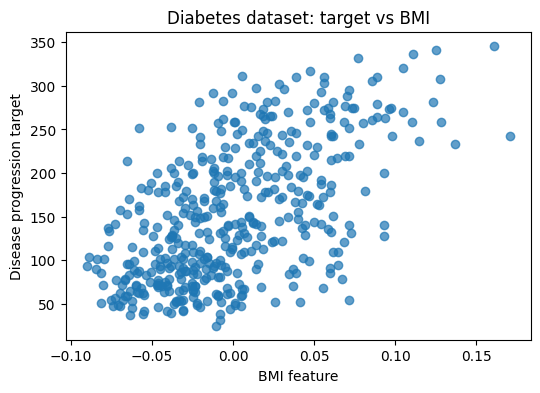

In [4]:
x = df["bmi"].to_numpy()
y = df["target"].to_numpy()

plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("BMI feature")
plt.ylabel("Disease progression target")
plt.title("Diabetes dataset: target vs BMI")
plt.show()

## 3. Train-test split

We will create a training set and a test set.  
The model will be fit on the training set, and we will evaluate its prediction error on the test set.


In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=2026
)

print("Training size:", len(x_train))
print("Test size:", len(x_test))

Training size: 331
Test size: 111


## 3.1 K-fold Cross-Validation

To get a more robust evaluation of our simple linear regression model, we can use k-fold cross-validation. This involves splitting the data into 'k' folds, and for each fold, training the model on k-1 folds and testing on the remaining fold.

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=2026)

# Lists to store MSEs for each fold
train_mses_kf = []
test_mses_kf = []

print("Starting K-Fold Cross-Validation...")

for fold, (train_index, test_index) in enumerate(kf.split(x)):
    x_train_kf, x_test_kf = x[train_index], x[test_index]
    y_train_kf, y_test_kf = y[train_index], y[test_index]

    # Run gradient descent on the current fold's training data
    b0_kf, b1_kf, hist_kf = gradient_descent_simple(
        x_train_kf, y_train_kf, lr=0.5, n_iter=2000, b0_init=0.0, b1_init=0.0
    )

    # Calculate training and test MSE for the current fold
    current_train_mse = mse(y_train_kf, predict_simple(x_train_kf, b0_kf, b1_kf))
    current_test_mse = mse(y_test_kf, predict_simple(x_test_kf, b0_kf, b1_kf))

    train_mses_kf.append(current_train_mse)
    test_mses_kf.append(current_test_mse)

    print(f"Fold {fold + 1}:")
    print(f"  Training MSE: {current_train_mse:.4f}")
    print(f"  Test MSE: {current_test_mse:.4f}")

print("\nK-Fold Cross-Validation Results:")
print(f"Average Training MSE across folds: {np.mean(train_mses_kf):.4f}")
print(f"Average Test MSE across folds: {np.mean(test_mses_kf):.4f}")

## 4. Prediction function and cost function

For simple linear regression, the model is

$$
\hat{y} = b_0 + b_1 x
$$

and the loss function is the mean squared error:

$$
\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Gradient descent updates the parameters to reduce this loss.


In [6]:
def predict_simple(x, b0, b1):
    return b0 + b1 * x

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


## 5. Visual intuition: the regression line and the loss

A regression line is determined by two parameters: the intercept `b0` and the slope `b1`.

Different choices of `b0` and `b1` produce different fitted lines, and each line gives a different mean squared error **on the training data**. ***[jx: The MSE depends on the training data, which is a training error. But we need to care more about the validation error. ]***

In the next example, we try several parameter combinations, plot the corresponding lines, and compare their training MSE values.

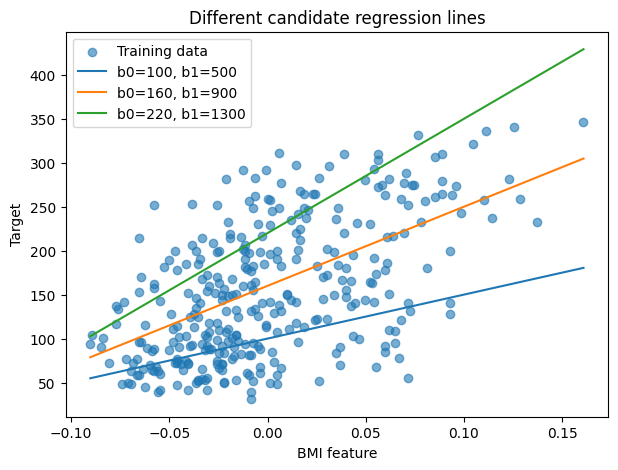

b0=100, b1=500, training MSE=7265.014
b0=160, b1=900, training MSE=4071.013
b0=220, b1=1300, training MSE=8794.040


In [7]:
candidate_lines = [
    (100, 500),
    (160, 900),
    (220, 1300),
]

plt.figure(figsize=(7,5))
plt.scatter(x_train, y_train, alpha=0.6, label="Training data")

x_line = np.linspace(x_train.min(), x_train.max(), 100)
for b0, b1 in candidate_lines:
    plt.plot(x_line, predict_simple(x_line, b0, b1), label=f"b0={b0}, b1={b1}")

plt.xlabel("BMI feature")
plt.ylabel("Target")
plt.title("Different candidate regression lines")
plt.legend()
plt.show()

for b0, b1 in candidate_lines:
    loss = mse(y_train, predict_simple(x_train, b0, b1))
    print(f"b0={b0}, b1={b1}, training MSE={loss:.3f}")

## 6. Gradient descent from scratch

For simple linear regression, the gradients of the MSE are:

$$\frac{\partial MSE}{\partial b_0} = \frac{2}{n} \sum (\hat{y}_i - y_i)$$

$$\frac{\partial MSE}{\partial b_1} = \frac{2}{n} \sum (\hat{y}_i - y_i)x_i
$$

We will implement the parameter updates directly.


### Define the **gradient descent algorithm**

The following function updates `b0` and `b1` iteratively and stores the loss values across iterations.

In [12]:
def gradient_descent_simple(x, y, lr=0.1, n_iter=2000, b0_init=0.0, b1_init=0.0):
    b0 = b0_init
    b1 = b1_init

    history = {
        "loss": [mse(y, predict_simple(x, b0, b1))],
        "b0": [b0],
        "b1": [b1]
    }

    n = len(x)

    for _ in range(n_iter):
        y_hat = predict_simple(x, b0, b1)
        error = y_hat - y

        # Here areis the gradients of the MSA for b0 and b1
        grad_b0 = (2 / n) * np.sum(error)
        grad_b1 = (2 / n) * np.sum(error * x)

        # lr is the learning rate, which controls the step size of each parameter update.
        b0 = b0 - lr * grad_b0
        b1 = b1 - lr * grad_b1


        history["loss"].append(mse(y, predict_simple(x, b0, b1)))
        history["b0"].append(b0)
        history["b1"].append(b1)

    return b0, b1, history

### Run gradient descent

We start from initial values of `b0 = 0` and `b1 = 0`, then run gradient descent on the training data.

In [13]:
b0_gd, b1_gd, hist = gradient_descent_simple(
    x_train, y_train, lr=0.5, n_iter=2000, b0_init=0.0, b1_init=0.0
)

print("Gradient descent estimates")
print("Intercept:", round(b0_gd, 4))
print("Slope:", round(b1_gd, 4))
print("Final training loss:", round(hist["loss"][-1], 4))

Gradient descent estimates
Intercept: 153.7095
Slope: 884.9406
Final training loss: 4031.5873


### Plot the loss over iterations

The following plot shows how the training MSE changes during optimization.

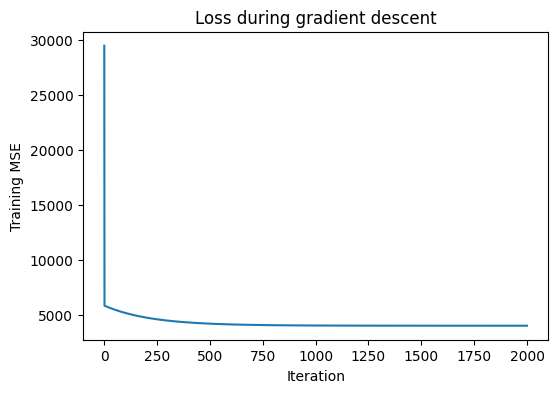

In [14]:
plt.figure(figsize=(6,4))
plt.plot(hist["loss"])
plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Loss during gradient descent")
plt.show()

### Plot the fitted regression line

We now plot the fitted line from gradient descent on top of the training data.

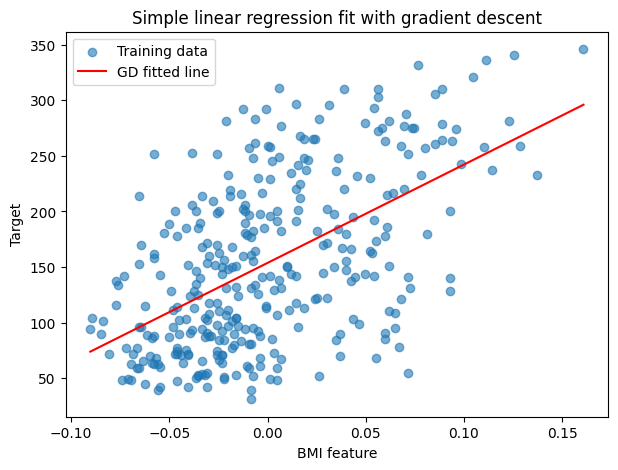

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(x_train, y_train, alpha=0.6, label="Training data")

x_line = np.linspace(x_train.min(), x_train.max(), 100)
plt.plot(x_line, predict_simple(x_line, b0_gd, b1_gd), color="red", label="GD fitted line")

plt.xlabel("BMI feature")
plt.ylabel("Target")
plt.title("Simple linear regression fit with gradient descent")
plt.legend()
plt.show()

## 7. Compare with the closed-form OLS solution

For ordinary least squares, the solution can also be obtained analytically:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

For this simple case, gradient descent and OLS should end up at very similar values when optimization works properly.


In [16]:
X_design = np.column_stack([np.ones(len(x_train)), x_train])
beta_ols = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y_train)

b0_ols, b1_ols = beta_ols
print("OLS estimates")
print("Intercept:", round(b0_ols, 4))
print("Slope:", round(b1_ols, 4))

OLS estimates
Intercept: 153.7108
Slope: 894.1813


In [17]:
train_mse_gd = mse(y_train, predict_simple(x_train, b0_gd, b1_gd))
test_mse_gd = mse(y_test, predict_simple(x_test, b0_gd, b1_gd))

train_mse_ols = mse(y_train, predict_simple(x_train, b0_ols, b1_ols))
test_mse_ols = mse(y_test, predict_simple(x_test, b0_ols, b1_ols))

print("Comparison")
print(f"GD  - train MSE: {train_mse_gd:.4f}, test MSE: {test_mse_gd:.4f}")
print(f"OLS - train MSE: {train_mse_ols:.4f}, test MSE: {test_mse_ols:.4f}")

Comparison
GD  - train MSE: 4031.5873, test MSE: 3516.9714
OLS - train MSE: 4031.3923, test MSE: 3507.6005


## 8. Learning rate experiments

The learning rate controls the step size of each parameter update.

A smaller learning rate may lead to slower convergence, while a larger learning rate may speed up optimization. However, if the learning rate is too large, the updates may become inefficient or unstable, and the algorithm may fail to reach a good solution.

The following example compares several learning rates on the same training data.

[ *jx:If the curve is flat or decreases very slowly (like lr=0.0001 might, if it needed more iterations to match others): Your learning rate might be too small. It's taking tiny steps and convergence is slow. You could try increasing it.
If the curve is erratic, oscillates, or even increases (like lr = 3): Your learning rate is likely too large. It's overshooting the minimum, leading to instability or divergence. You need to decrease it.
If the curve decreases quickly and smoothly to a plateau: You're likely in a good range for the learning rate.重要的是要找到这个拐点，你才能找到最合适的learning rate。

Observing the "changing point" or "inflection point" in the loss curve is indeed a key insight when tuning the learning rate. It helps you understand the learning dynamics.

*   Before the '拐点': The loss is decreasing rapidly, indicating that the model is making good progress in learning.
*   At/Around the '拐点': This is often where the rate of improvement slows down significantly. The curve starts to flatten out, suggesting that the model is approaching a minimum.
*  After the '拐点': The loss has mostly stabilized, meaning further iterations with the same learning rate might yield diminishing returns, or if the learning rate is too high, it might start oscillating or even diverge.

*]






lr=0.0001, final training MSE=27630.9767
lr=0.01, final training MSE=5831.5597
lr=0.1, final training MSE=5552.3820
lr=1, final training MSE=27912.0547


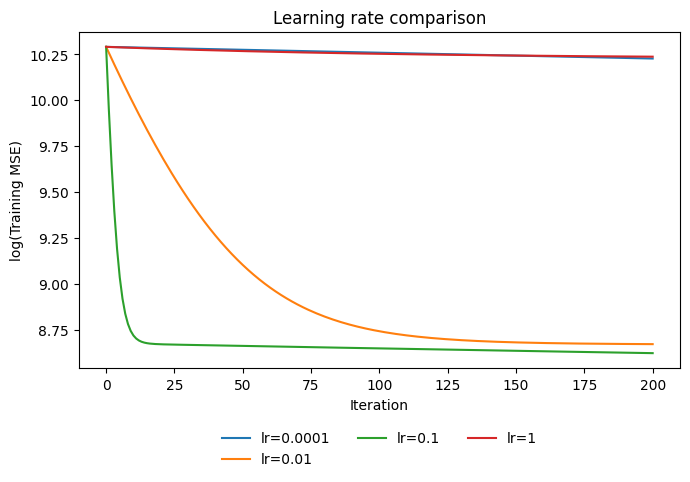

In [24]:
learning_rates = [0.0001, 0.01, 0.1, 1]

plt.figure(figsize=(7,5))
for lr in learning_rates:
    _, _, h = gradient_descent_simple(x_train, y_train, lr=lr, n_iter=2000)
    plt.plot(np.log(h["loss"]), label=f"lr={lr}")
    print(f"lr={lr}, final training MSE={h['loss'][-1]:.4f}")

plt.xlabel("Iteration")
plt.ylabel("log(Training MSE)")
plt.title("Learning rate comparison")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

### Brief interpretation

Look at the curves above.
- Which learning rate decreases loss most smoothly?
- Which one is slow?


**Jx reflection:
1.   the line(lr = 0.01) is smooth, but I did not observed the apartment changing point. comparing to the line (lr = 0.1) with an obvious changing point, which we can tell from the comparision, the changing point is between 0.01 to O.1. so, next step, we can narrow down the learning rate between 0.01 to 0.1.
2.   As for the line of 0.0001 and 1, they are too slow or too fast/unstable which contain limited information for us to detect the optimal learning rate. if too slow, the insufficient progress to slow convergence. For the too fast, it is instability or divergence. **




## 9. Multivariable regression

Now we move from one predictor to **multiple predictors** using the same Diabetes dataset.


In [25]:
feature_cols = df.drop(columns=["target"]).columns.tolist()
X = df[feature_cols].to_numpy()
y_multi = df["target"].to_numpy()

X_train, X_test, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.25, random_state=2026
)

print("Features used:", feature_cols)
print("X_train shape:", X_train.shape)

Features used: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X_train shape: (331, 10)


### Matrix-based gradient descent

For multivariable linear regression, it is more convenient to write the model in matrix form:

$$
\hat{\mathbf{y}} = X\beta
$$

where \(X\) is the design matrix and $\beta$ is the coefficient vector.

Using MSE as the loss function, the gradient with respect to $\beta$ is:

$$
\nabla_\beta \mathrm{MSE} = \frac{2}{n} X^\top (X\beta - \mathbf{y})
$$

The following functions add an intercept column to the design matrix, compute predictions, and implement gradient descent for the full coefficient vector.

In [26]:
def add_intercept(X):
    return np.column_stack([np.ones(X.shape[0]), X])

def predict_matrix(X, beta):
    return X @ beta

def gradient_descent_matrix(X, y, lr=0.01, n_iter=2000, beta_init=None):
    X1 = add_intercept(X)
    n, p = X1.shape

    if beta_init is None:
        beta = np.zeros(p)
    else:
        beta = beta_init.copy()

    loss_history = [mse(y, predict_matrix(X1, beta))]

    for _ in range(n_iter):
        y_hat = predict_matrix(X1, beta)
        error = y_hat - y
        grad = (2 / n) * (X1.T @ error)
        beta = beta - lr * grad
        loss_history.append(mse(y, predict_matrix(X1, beta)))

    return beta, loss_history

## 11. Why feature scaling matters

In multivariable regression, gradient descent updates all coefficients at the same time.

When predictors are on different scales, the optimization path can become harder to tune, and the same learning rate may not work equally well across variables.

We therefore examine the predictors first, then compare gradient descent with and without z-score standardization.


### Check the scale of the predictors

The following summary shows the mean, standard deviation, minimum, and maximum of each predictor in the training set.

In [27]:
for i, col in enumerate(feature_cols):
    print(
        f"{col:>4} | mean={X_train[:, i].mean():.4f} | "
        f"std={X_train[:, i].std():.4f} | "
        f"min={X_train[:, i].min():.4f} | max={X_train[:, i].max():.4f}"
    )

 age | mean=0.0008 | std=0.0479 | min=-0.1072 | max=0.1107
 sex | mean=-0.0023 | std=0.0474 | min=-0.0446 | max=0.0507
 bmi | mean=-0.0001 | std=0.0478 | min=-0.0903 | max=0.1609
  bp | mean=0.0015 | std=0.0479 | min=-0.1124 | max=0.1320
  s1 | mean=-0.0016 | std=0.0453 | min=-0.1268 | max=0.1525
  s2 | mean=-0.0009 | std=0.0457 | min=-0.1128 | max=0.1988
  s3 | mean=0.0005 | std=0.0482 | min=-0.1023 | max=0.1812
  s4 | mean=-0.0011 | std=0.0466 | min=-0.0764 | max=0.1852
  s5 | mean=-0.0015 | std=0.0455 | min=-0.1261 | max=0.1336
  s6 | mean=-0.0006 | std=0.0468 | min=-0.1378 | max=0.1356


### Standardize the predictors

We now apply z-score standardization to the predictors using the training-set mean and standard deviation.

The same transformation is then applied to the test set.

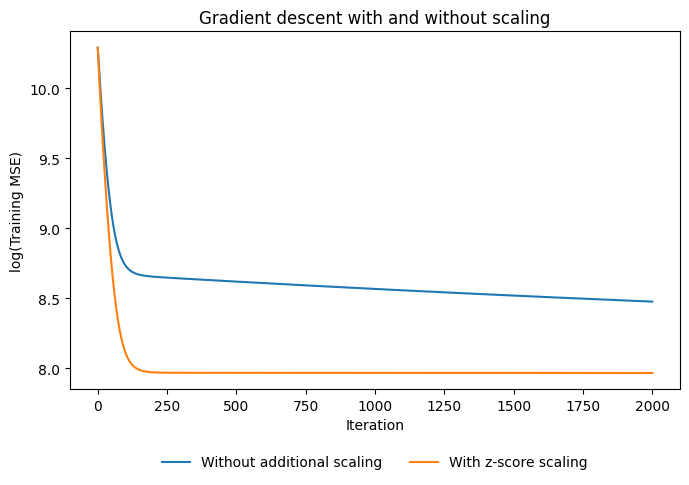

Final training MSE without scaling: 4794.0862
Final training MSE with scaling: 2877.7867


In [28]:
X_train_scaled = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
X_test_scaled = (X_test - X_train.mean(axis=0)) / X_train.std(axis=0)

lr_compare = 0.01

beta_raw, loss_raw = gradient_descent_matrix(
    X_train, y_train_multi, lr=lr_compare, n_iter=2000
)

beta_scaled, loss_scaled = gradient_descent_matrix(
    X_train_scaled, y_train_multi, lr=lr_compare, n_iter=2000
)

plt.figure(figsize=(7,5))
plt.plot(np.log(loss_raw), label="Without additional scaling")
plt.plot(np.log(loss_scaled), label="With z-score scaling")
plt.xlabel("Iteration")
plt.ylabel("log(Training MSE)")
plt.title("Gradient descent with and without scaling")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

print(f"Final training MSE without scaling: {loss_raw[-1]:.4f}")
print(f"Final training MSE with scaling: {loss_scaled[-1]:.4f}")

### Brief exploration

Look at the two optimization curves above and briefly reflect on the following questions:

1. Which version reaches the lower training loss after the same number of iterations?
2. Why might scaling make gradient descent easier to optimize in the multivariable setting?


## 12. Closed-form benchmark for the multivariable case

In [29]:
X_train_design = add_intercept(X_train)
beta_ols_multi = np.linalg.inv(X_train_design.T @ X_train_design) @ (X_train_design.T @ y_train_multi)

train_mse_ols_multi = mse(y_train_multi, predict_matrix(X_train_design, beta_ols_multi))
test_mse_ols_multi = mse(y_test_multi, predict_matrix(add_intercept(X_test), beta_ols_multi))

train_mse_gd_raw = mse(y_train_multi, predict_matrix(add_intercept(X_train), beta_raw))
test_mse_gd_raw = mse(y_test_multi, predict_matrix(add_intercept(X_test), beta_raw))

train_mse_gd_scaled = mse(y_train_multi, predict_matrix(add_intercept(X_train_scaled), beta_scaled))
test_mse_gd_scaled = mse(y_test_multi, predict_matrix(add_intercept(X_test_scaled), beta_scaled))

print("Multivariable comparison")
print(f"OLS                train MSE: {train_mse_ols_multi:.4f}, test MSE: {test_mse_ols_multi:.4f}")
print(f"GD unscaled        train MSE: {train_mse_gd_raw:.4f}, test MSE: {test_mse_gd_raw:.4f}")
print(f"GD scaled          train MSE: {train_mse_gd_scaled:.4f}, test MSE: {test_mse_gd_scaled:.4f}")

Multivariable comparison
OLS                train MSE: 2870.8068, test MSE: 2931.3278
GD unscaled        train MSE: 4794.0862, test MSE: 4886.3995
GD scaled          train MSE: 2877.7867, test MSE: 2973.3744


## 13. A simple debugging checklist

When gradient descent does not behave as expected, check the following:

1. **Is the loss decreasing?**  
   If not, the learning rate may be too large, or the gradient formula may be wrong.

2. **Is convergence very slow?**  
   The learning rate may be too small.

3. **Are predictors on very different scales?**  
   Standardization may help.

4. **Does gradient descent roughly agree with OLS for linear regression?**  
   If not, review the update rule and loss function.

5. **Are you evaluating on a separate test set?**  
   Training loss alone is not enough.


## 14. Additional practice

Try the following modifications:

1. Replace `bmi` with another single predictor such as `bp` or `s5`.  
2. Change the learning rate and compare the loss curves again.  
3. Increase the number of iterations and see whether the estimates move closer to OLS.  
4. Remove predictors in the multivariable section.  
5. Compare training and test error after each change.
